<a href="https://colab.research.google.com/github/SalgadoHUB/Classical_Mechanics_II/blob/main/Problemas/Tema2/Problema_2c_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Momento Angular de un Sistema de 3 partículas

Un cuerpo rígido está formado por tres partículas de masa $m$, $2m$ y $4m$ situadas inicialmente en los puntos:

- $(2a, 0, 2a)$
- $(a, -2a, -a)$
- $(-a, a, 0)$

respectivamente. El cuerpo gira alrededor del origen con una velocidad angular:

$$ \boldsymbol{\omega} = b(3\hat{i} - 2\hat{j} + 4\hat{k}) $$

### Cuestiones

a). **Calcule el momento angular usando la relación matricial:**
   $$ \boldsymbol{J} = \mathbb{I} \cdot \boldsymbol{\omega} $$

b). **Calcule el momento angular usando la definición vectorial:**
   $$ J_i = \mathbf{r}_i \times m_i \mathbf{v}_i = m_i \mathbf{r}_i \times (\boldsymbol{\omega} \times \mathbf{r}_i) $$

c). **Calcule los ejes principales de inercia:**
   - Encuentra una base de ejes principales de inercia.
   - Expresa en esta base:
     - $ \mathbb{I} $ (tensor de inercia)
     - $ \boldsymbol{\omega} $ (velocidad angular)
     - $ \boldsymbol{J} $ (momento angular)

## Dibujamos el sistema

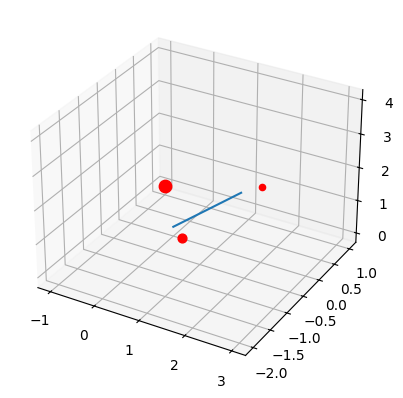

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Creamos una figura
figura = plt.figure()

# Creamos el eje
eje = figura.add_subplot(111, projection='3d')
# Utilizamos la función scatter para dibujar el vector en el eje 3D
eje.scatter(2,0,2, c='r', marker='o', s=20)
eje.scatter(1,-1,1, c='r', marker='o', s=2*20)
eje.scatter(-1,1,0, c='r', marker='o', s=4*20)

eje.plot([0,3],[0,-2],[0,4])

# Mostramos el resultado en una ventana
plt.show()

## Definimos las variables del enunciado

In [ ]:
import sympy as smp

m, a, b = smp.symbols('m a b')

m1 = m
m2 = 2*m
m3 = 4*m

r1 = smp.Matrix([2*a, 0, 2*a])
r2 = smp.Matrix([a, -2*a, -a])
r3 = smp.Matrix([-a, a, 0])

w = b*smp.Matrix([3, -2, 4])

Buscamos su centro de masas, para comprobar que el eje de rotación pasa por el $CDM$ (no lo pide en el enunciado).

In [ ]:
R = (m1*r1 + m2*r2 + m3*r3) / (m1+m2+m3)
R

Matrix([
[0],
[0],
[0]])

## a) Usando la matriz de inercia

Calculamos los elementos de la matriz de inercia.

In [ ]:
Ixx = m1*(r1[1]**2 + r1[2]**2) + m2*(r2[1]**2 + r2[2]**2) + m3*(r3[1]**2 + r3[2]**2)
Iyy = m1*(r1[0]**2 + r1[2]**2) + m2*(r2[0]**2 + r2[2]**2) + m3*(r3[0]**2 + r3[2]**2)
Izz = m1*(r1[0]**2 + r1[1]**2) + m2*(r2[0]**2 + r2[1]**2) + m3*(r3[0]**2 + r3[1]**2)

Ixy = -m1*(r1[0]*r1[1]) - m2*(r2[0]*r2[1]) - m3*(r3[0]*r3[1])
Ixz = -m1*(r1[0]*r1[2]) - m2*(r2[0]*r2[2]) - m3*(r3[0]*r3[2])
Iyz = -m1*(r1[1]*r1[2]) - m2*(r2[1]*r2[2]) - m3*(r3[1]*r3[2])
#
I = smp.Matrix([[Ixx, Ixy, Ixz], [Ixy, Iyy, Iyz], [Ixz, Iyz, Izz]])
I

Matrix([
[18*a**2*m,  8*a**2*m, -2*a**2*m],
[ 8*a**2*m, 16*a**2*m, -4*a**2*m],
[-2*a**2*m, -4*a**2*m, 22*a**2*m]])

Calculamos $J$ como:
$$ \boldsymbol{J} = \mathbb{I} \cdot \boldsymbol{\omega} $$

In [ ]:
J = I * w
J

Matrix([
[ 30*a**2*b*m],
[-24*a**2*b*m],
[ 90*a**2*b*m]])

## b) Usando la definición de $J$
Ahora usamos:
$$ J_i = \mathbf{r}_i \times m_i \mathbf{v}_i = m_i \mathbf{r}_i \times (\boldsymbol{\omega} \times \mathbf{r}_i) $$

In [ ]:
v1 = w.cross(r1)
v2 = w.cross(r2)
v3 = w.cross(r3)

J1 = r1.cross(m1*v1)
J2 = r2.cross(m2*v2)
J3 = r3.cross(m3*v3)

J = J1 + J2 + J3
J
#

Matrix([
[ 30*a**2*b*m],
[-24*a**2*b*m],
[ 90*a**2*b*m]])

Que coincide con lo calculado en el apartado (a).

## c). Cálculo de los ejes principales de inercia

Tenemos que diagnoalizar nuestra matriz. Por legibilidad, vamos a extraer el factor común de todos los elementos de la matriz, $2ma²$.

In [ ]:
I_factor = I/(2*m*a**2)
A, Id = I_factor.diagonalize()
I_factor

Matrix([
[ 9,  4, -1],
[ 4,  8, -2],
[-1, -2, 11]])

In [ ]:
Id.simplify()
smp.pprint('I diagonalizada:')
Id

I diagonalizada:


Matrix([
[14,           0,           0],
[ 0, 7 - sqrt(7),           0],
[ 0,           0, sqrt(7) + 7]])

In [ ]:
smp.pprint('Vectores propios:')
A

Vectores propios:


Matrix([
[-1, -sqrt(7) - 2, -2 + sqrt(7)],
[-1,  sqrt(7) + 3,  3 - sqrt(7)],
[ 1,            1,            1]])